In [1]:
# Base imports and path setting
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import jax
import jax.numpy as jnp
import diffrax as dfx
from time import time

import sys
import os
from os.path import dirname
cwd = os.getcwd()
sys.path.append(dirname(cwd))


In [2]:
# Relative import and configs
from src.flows import duffing, trajectory_plot, stream_plot
from src.lyapunov import flow_lyapunov_spectrum, make_batch_lyapunov_solver, kaplan_yorke_dim, boxcount_dimension, poincare_sos

FIG_PATH = dirname(cwd) + "/figs/"
jax.config.update("jax_enable_x64", True)
np.random.seed(42069)

In [3]:
# Flow selection
rhs = duffing
pars = {
    "c": 1,
    "d": -1,
    "a": 0.2,
    "b": 0.3,
    "w": 1,
}
# Initial condition, integration options
z0 = jnp.array([1, 1])
dt = 0.001
N_iters = 2e5
timesteps = np.linspace(0, dt*N_iters, 500000)

steps = 50
burns = 0.2

solver = dfx.Dopri5()
stepsc = dfx.ConstantStepSize()
term = dfx.ODETerm(rhs)
saveat = dfx.SaveAt(ts=timesteps)


In [1]:
# Animation of the flow

X_space = np.linspace(-10, 10, 400)
Y_space = np.linspace(-10, 10, 400)
starting_lines = np.array([np.concat((np.linspace(-7.5, -1, 200), np.linspace(-1, 1, 200), np.linspace(1, 7.5, 200)), ),
                           np.full(600, 1)
                           ]).T
X, Y = np.meshgrid(X_space, Y_space)
U, V = rhs(t=0, z=(X, Y), params=pars)
dens=3

fig, ax = plt.subplots()
stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)

def animate(ti):
    ax.clear()
    ax.grid(True)
    U, V = rhs(t=ti, z=(X, Y), params=pars)
    stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)
    print(ti)
    return stream

anim = animation.FuncAnimation(fig, animate, frames=np.linspace(0, 2*np.pi, 100), interval=50, blit=False, repeat=False)
anim.save(FIG_PATH + '/duffing.gif', fps=30)
# plt.show()


KeyboardInterrupt: 

In [4]:
# First experiment: lyapunov exponents for 100 random initial condition
flurry = jnp.array(np.random.rand(100, 2)*16 - 8)
t0_batch = jnp.zeros(len(flurry))

compute = make_batch_lyapunov_solver(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns), jacobian=False)
batched_lyap = jax.jit(
    jax.vmap(compute, in_axes=(0, 0, None, None))
)

trajs, cum_lyaps = batched_lyap(flurry, t0_batch, pars, steps*dt)


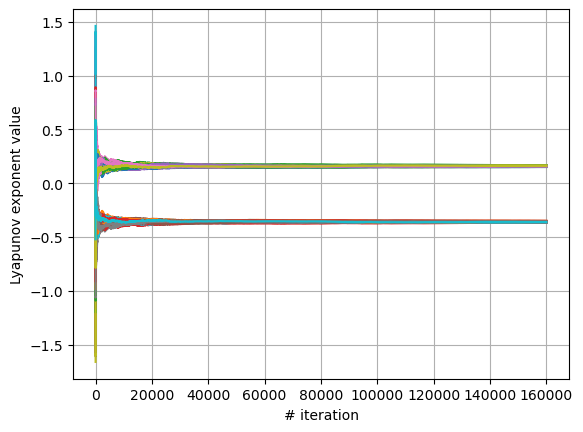

Lyapunov exponent extimate (averaged over random trajectories): [ 0.15773714 -0.35773714] +- [0.00330019 0.00330019]


In [5]:
# Plot results
for cum in cum_lyaps:
    plt.plot(cum)
plt.grid(True)
plt.xlabel("# iteration"); plt.ylabel("Lyapunov exponent value")
plt.savefig(FIG_PATH + "Flurry_duffing.png", dpi=1500)
plt.show()
lyap_ext = cum_lyaps.mean(axis=0)[-1, :]
lyap_std = cum_lyaps.std(axis=0)[-1, :]
print(f"Lyapunov exponent extimate (averaged over random trajectories): {lyap_ext} +- {lyap_std}")